# 03 — E-Waste Clustering using K-Means on ResNet18 Embeddings
**Project:** E-Waste Component Classification | SDG 12.4  
**Technique:** Clustering (K-Means) + t-SNE Visualisation  
**Depends on:** 02_cnn_classification.ipynb (trained model required)

## Cell 1 — Imports

In [1]:
import os
import json
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import (silhouette_score, adjusted_rand_score,
                              normalized_mutual_info_score)
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Clustering notebook ready.")

Clustering notebook ready.


## Cell 2 — Configuration

In [2]:
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = str(PROJECT_ROOT / "data")
MODEL_PATH = PROJECT_ROOT / "models" / "classification" / "resnet18" / "resnet18_best.pth"
if not MODEL_PATH.exists():
    MODEL_PATH = PROJECT_ROOT / "models" / "cnn_resnet18" / "resnet18_best.pth"
CLUSTER_DIR = PROJECT_ROOT / "models" / "clustering"
os.makedirs(CLUSTER_DIR, exist_ok=True)

IMG_SIZE    = 224
BATCH_SIZE  = 16
NUM_WORKERS = 0
NUM_CLASSES = 18

# Hazard mapping — used for cluster validation
HAZARD_MAP = {
    "Battery": "HIGH",            "PCB": "HIGH",
    "Mobile": "HIGH",             "Television": "HIGH",
    "Laptop": "HIGH",             "light bulbs": "HIGH",
    "Refrigerator": "HIGH",       "Air-Conditioner": "HIGH",
    "Microwave": "MEDIUM",        "Washing Machine": "MEDIUM",
    "Printer": "MEDIUM",          "Microchip-IC": "MEDIUM",
    "Keyboard": "LOW",            "Mouse": "LOW",
    "Resistor": "LOW",            "transistor": "LOW",
    "heat-sink": "LOW",           "Passive-Component": "LOW",
}
HAZARD_COLORS = {"HIGH": "#e74c3c", "MEDIUM": "#f39c12", "LOW": "#27ae60"}

## Cell 3 — Load Dataset (Test Split for Clustering)

In [3]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Use full dataset (train+val+test) for richer embedding space
from torch.utils.data import ConcatDataset

train_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=transform)
val_ds   = datasets.ImageFolder(os.path.join(DATA_DIR, "val"),   transform=transform)
test_ds  = datasets.ImageFolder(os.path.join(DATA_DIR, "test"),  transform=transform)

full_dataset = ConcatDataset([train_ds, val_ds, test_ds])
full_loader  = DataLoader(full_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)

CLASS_NAMES = train_ds.classes
NUM_CLASSES = len(CLASS_NAMES)
print(f"Classes    : {CLASS_NAMES}")
print(f"Num classes: {NUM_CLASSES}")
print(f"Total imgs : {len(full_dataset)}")

Classes    : ['Air-Conditioner', 'Battery', 'Keyboard', 'Laptop', 'Microchip-IC', 'Microwave', 'Mobile', 'Mouse', 'PCB', 'Passive-Component', 'Printer', 'Refrigerator', 'Resistor', 'Television', 'Washing Machine', 'heat-sink', 'light bulbs', 'transistor']
Num classes: 18
Total imgs : 27399


## Cell 4 — Load Trained ResNet18 as Feature Extractor

In [4]:
def build_resnet18_extractor(num_classes, model_path):
    model = models.resnet18(weights=None)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Linear(512, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)
    )
    model.load_state_dict(torch.load(model_path, map_location=device))

    # Remove final classification head — keep up to avgpool
    # This gives us 512-dim embeddings
    extractor = nn.Sequential(*list(model.children())[:-1])
    extractor.eval()
    return extractor

extractor = build_resnet18_extractor(NUM_CLASSES, MODEL_PATH)
print("Feature extractor ready — output: 512-dim embeddings")

Feature extractor ready — output: 512-dim embeddings


## Cell 5 — Extract Embeddings

In [6]:
print("Extracting embeddings from all images using GPU...")

# 1. CRITICAL: Move model to GPU and set to evaluation mode
extractor = extractor.to(device)
extractor.eval()

all_embeddings = []

# Build label list across all splits (ensure these match your dataset objects)
split_labels = (
    [label for _, label in train_ds.samples] +
    [label for _, label in val_ds.samples]   +
    [label for _, label in test_ds.samples]
)

with torch.no_grad():
    # 2. Use modern autocast for CUDA 12.8 speed boost
    with torch.amp.autocast('cuda'):
        for i, (images, _) in enumerate(tqdm(full_loader, desc="Extracting")):
            # Move data to GPU
            images = images.to(device)
            
            # Forward pass
            feats = extractor(images)
            
            # 3. Flexible squeezing (handles both ViT and CNN outputs)
            if len(feats.shape) > 2:
                feats = feats.squeeze(-1).squeeze(-1)
            
            # Move result back to CPU for numpy storage
            all_embeddings.append(feats.cpu().numpy())

# Stack all chunks into one large matrix
all_embeddings = np.vstack(all_embeddings)
all_labels = np.array(split_labels)

print(f"Embeddings shape : {all_embeddings.shape}")
print(f"Labels shape     : {all_labels.shape}")

# Standardise embeddings
scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(all_embeddings)
print("Embeddings standardised.")

Extracting embeddings from all images using GPU...


Extracting:  69%|██████▊   | 1177/1713 [01:13<00:29, 17.97it/s]c:\Users\Student\Downloads\ewaste_vit_project\.venv\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Extracting: 100%|██████████| 1713/1713 [01:59<00:00, 14.39it/s]


Embeddings shape : (27399, 512)
Labels shape     : (27399,)
Embeddings standardised.


## Cell 6 — K-Means Clustering

In [7]:
# We cluster into 3 groups = HIGH / MEDIUM / LOW hazard
N_CLUSTERS = 3

print(f"Running K-Means with {N_CLUSTERS} clusters...")
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10, max_iter=300)
cluster_labels = kmeans.fit_predict(embeddings_scaled)

# Evaluation metrics
sil  = silhouette_score(embeddings_scaled, cluster_labels, sample_size=2000)
ari  = adjusted_rand_score(all_labels, cluster_labels)
nmi  = normalized_mutual_info_score(all_labels, cluster_labels)

print(f"Silhouette Score         : {sil:.4f}  (higher is better, max=1)")
print(f"Adjusted Rand Index      : {ari:.4f}  (higher is better, max=1)")
print(f"Normalized Mutual Info   : {nmi:.4f}  (higher is better, max=1)")

# Save cluster assignments
np.save(os.path.join(CLUSTER_DIR, "embeddings.npy"), all_embeddings)
np.save(os.path.join(CLUSTER_DIR, "labels.npy"), all_labels)
np.save(os.path.join(CLUSTER_DIR, "cluster_labels.npy"), cluster_labels)
print("Cluster data saved.")

Running K-Means with 3 clusters...
Silhouette Score         : 0.0618  (higher is better, max=1)
Adjusted Rand Index      : 0.1612  (higher is better, max=1)
Normalized Mutual Info   : 0.3977  (higher is better, max=1)
Cluster data saved.


## Cell 7 — Elbow Curve (Optimal K Analysis)

Computing elbow curve (K=2 to 10)...


Elbow: 100%|██████████| 9/9 [00:15<00:00,  1.74s/it]


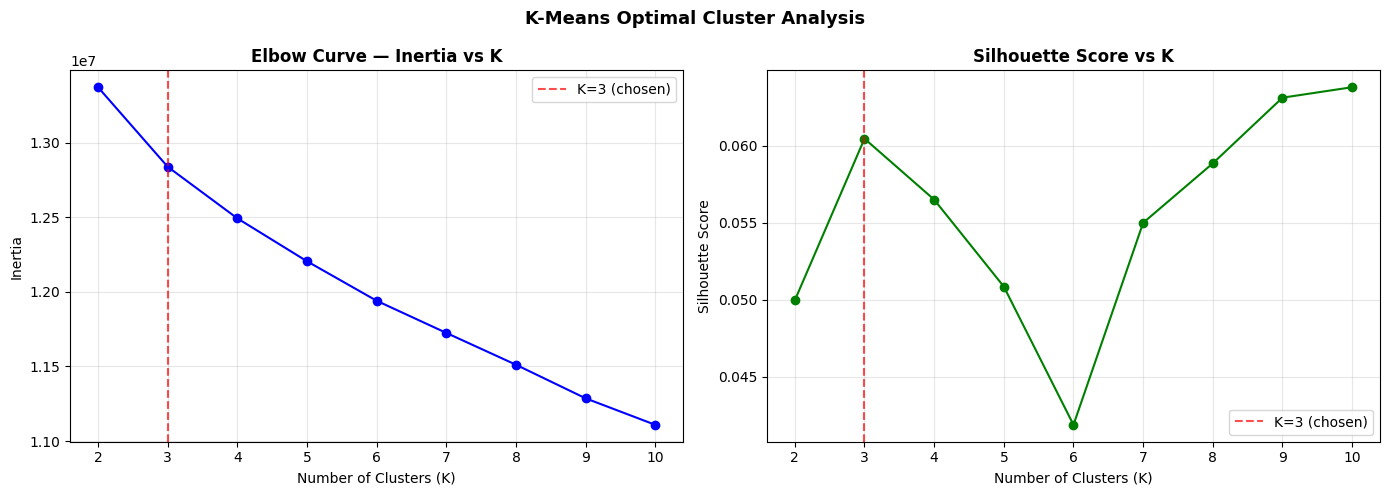

Elbow curve saved.


In [8]:
print("Computing elbow curve (K=2 to 10)...")
inertias    = []
sil_scores  = []
k_range     = range(2, 11)

for k in tqdm(k_range, desc="Elbow"):
    km = KMeans(n_clusters=k, random_state=42, n_init=5, max_iter=100)
    km.fit(embeddings_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(embeddings_scaled, km.labels_, sample_size=2000)
    sil_scores.append(sil)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertias, "b-o", markersize=6)
ax1.axvline(x=3, color="red", linestyle="--", alpha=0.7, label="K=3 (chosen)")
ax1.set_title("Elbow Curve — Inertia vs K", fontsize=12, fontweight="bold")
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("Inertia")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(k_range, sil_scores, "g-o", markersize=6)
ax2.axvline(x=3, color="red", linestyle="--", alpha=0.7, label="K=3 (chosen)")
ax2.set_title("Silhouette Score vs K", fontsize=12, fontweight="bold")
ax2.set_xlabel("Number of Clusters (K)")
ax2.set_ylabel("Silhouette Score")
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle("K-Means Optimal Cluster Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(CLUSTER_DIR, "elbow_curve.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Elbow curve saved.")

## Cell 8 — t-SNE Visualisation (by True Class)

Running t-SNE (this takes 5-15 mins on CPU)...
t-SNE done.


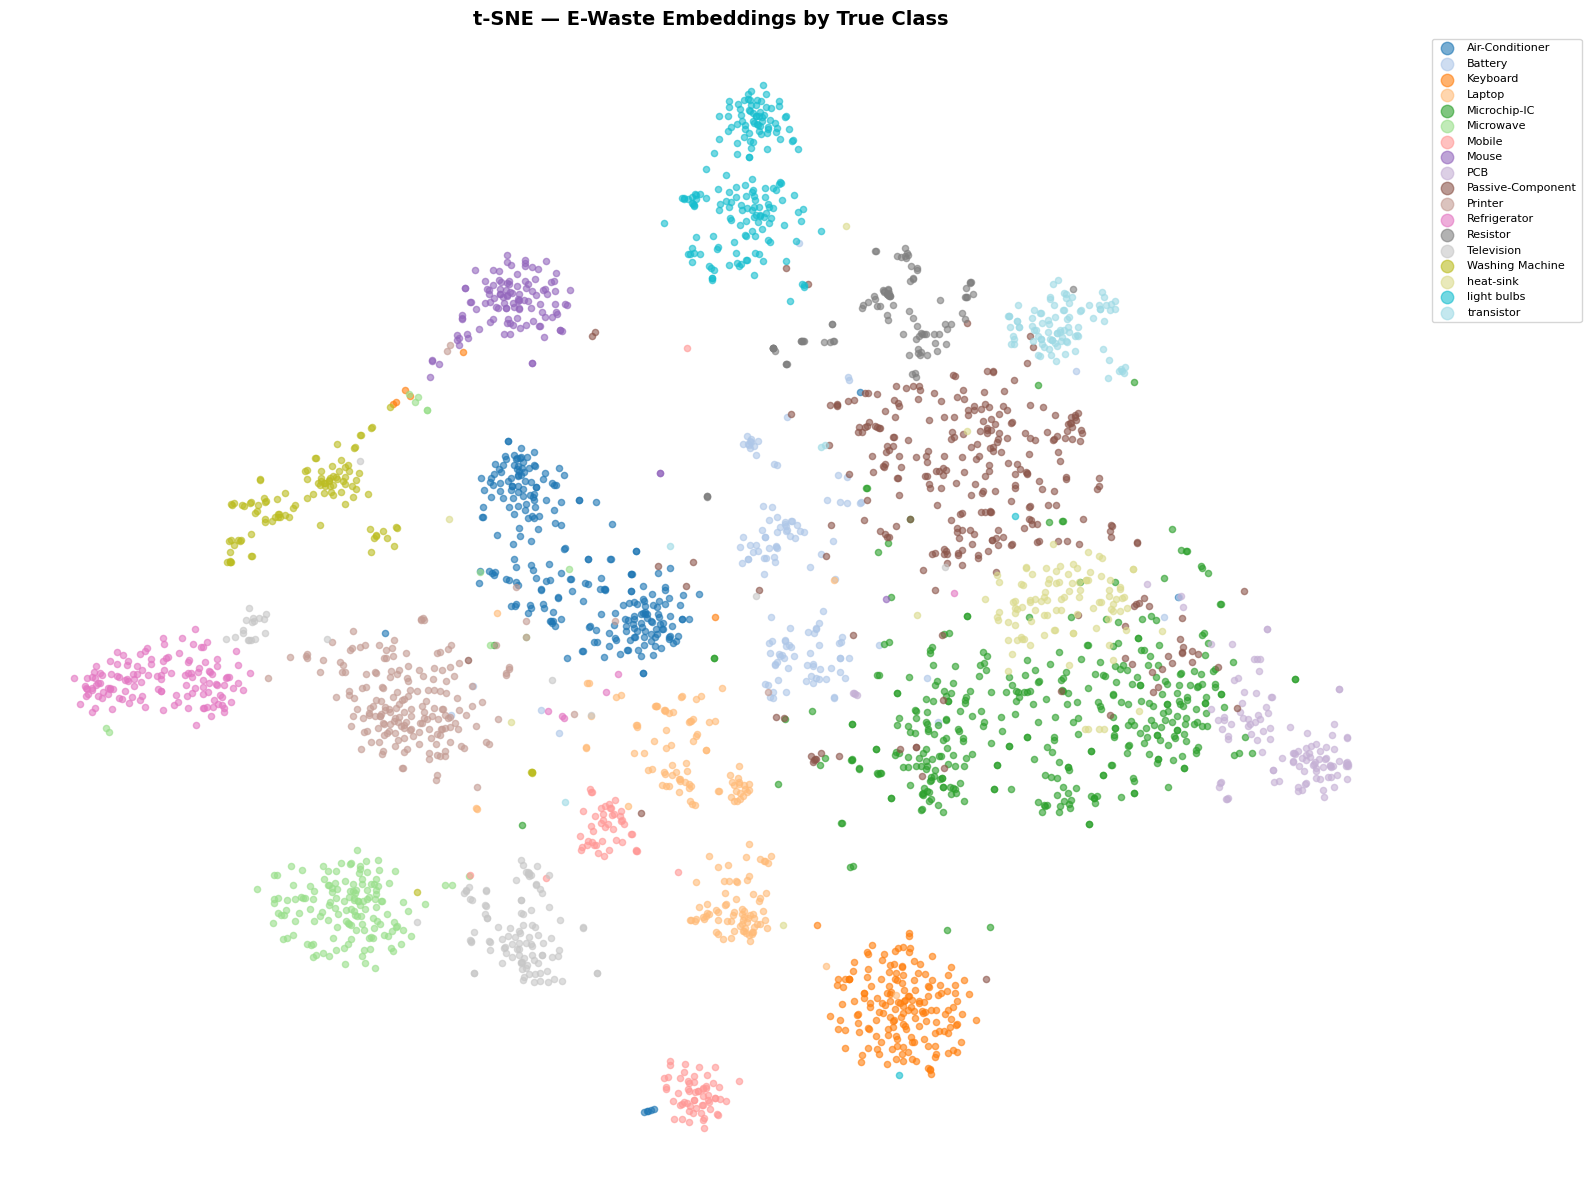

In [9]:
print("Running t-SNE (this takes 5-15 mins on CPU)...")
tsne = TSNE(n_components=2, perplexity=40, random_state=42, max_iter=1000)

# Sample 3000 points for speed
idx        = np.random.choice(len(embeddings_scaled), size=min(3000, len(embeddings_scaled)), replace=False)
emb_sample = embeddings_scaled[idx]
lbl_sample = all_labels[idx]
clu_sample = cluster_labels[idx]

tsne_result = tsne.fit_transform(emb_sample)
print("t-SNE done.")

# Plot by true class
plt.figure(figsize=(16, 12))
colors = plt.cm.tab20(np.linspace(0, 1, NUM_CLASSES))
for i, cls in enumerate(CLASS_NAMES):
    mask = lbl_sample == i
    plt.scatter(tsne_result[mask, 0], tsne_result[mask, 1],
                c=[colors[i]], label=cls, alpha=0.6, s=20)

plt.title("t-SNE — E-Waste Embeddings by True Class", fontsize=14, fontweight="bold")
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, markerscale=2)
plt.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(CLUSTER_DIR, "tsne_by_class.png"), dpi=150, bbox_inches="tight")
plt.show()

## Cell 9 — t-SNE Visualisation (by Hazard Level)

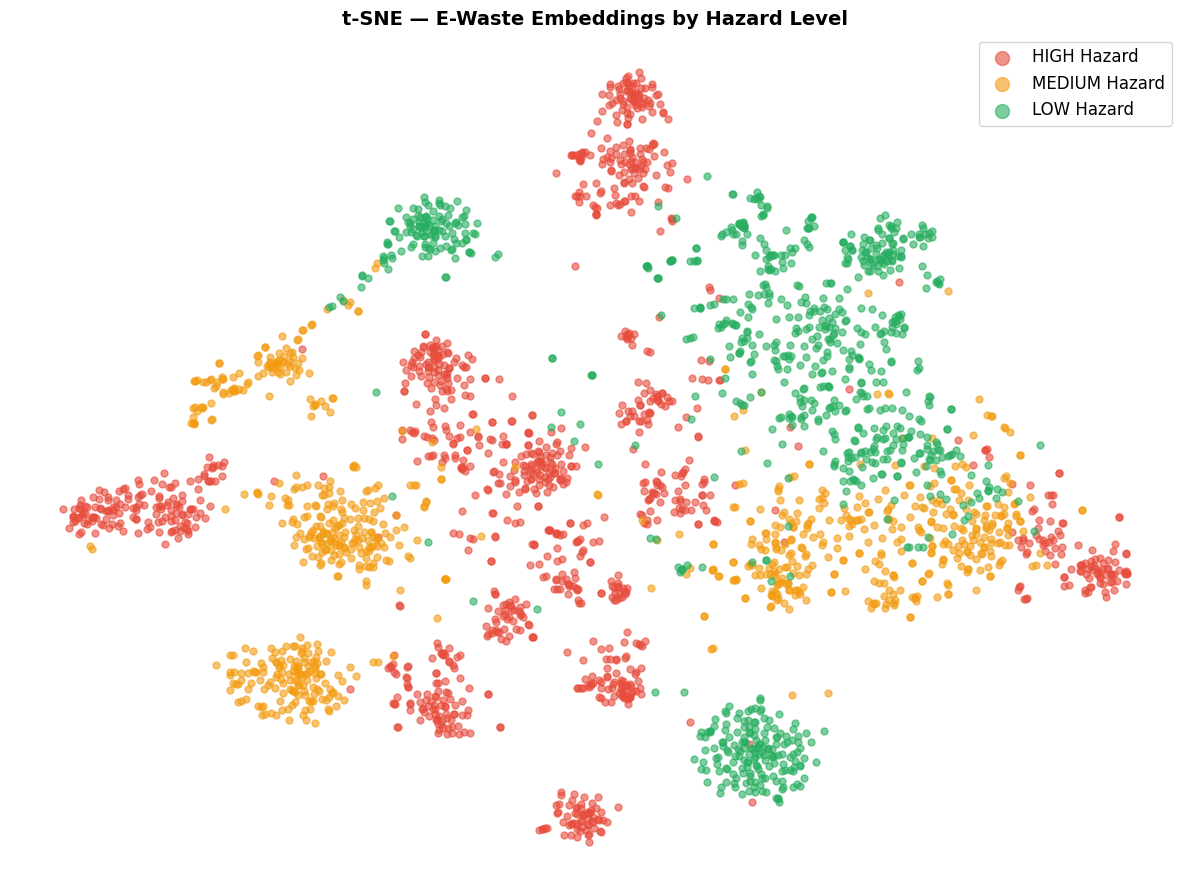

t-SNE plots saved.


In [10]:
# Map true labels to hazard level
hazard_levels = np.array([
    HAZARD_MAP.get(CLASS_NAMES[l], "MEDIUM") for l in lbl_sample
])

plt.figure(figsize=(12, 9))
for hazard in ["HIGH", "MEDIUM", "LOW"]:
    mask = hazard_levels == hazard
    plt.scatter(tsne_result[mask, 0], tsne_result[mask, 1],
                c=HAZARD_COLORS[hazard], label=f"{hazard} Hazard",
                alpha=0.6, s=25)

plt.title("t-SNE — E-Waste Embeddings by Hazard Level", fontsize=14, fontweight="bold")
plt.legend(fontsize=12, markerscale=2)
plt.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(CLUSTER_DIR, "tsne_by_hazard.png"), dpi=150, bbox_inches="tight")
plt.show()
print("t-SNE plots saved.")

## Cell 10 — Cluster Composition Analysis

Cluster Composition — which classes fall in each cluster:

Cluster 0 (7500 samples):
  Air-Conditioner                        97  [HIGH] █████████
  Battery                               544  [HIGH] ██████████████████████████████████████████████████████
  Keyboard                               40  [LOW] ████
  Laptop                                 51  [HIGH] █████
  Microchip-IC                           80  [MEDIUM] ████████
  Microwave                              10  [MEDIUM] █
  Mobile                                 27  [HIGH] ██
  Mouse                                 906  [LOW] ██████████████████████████████████████████████████████████████████████████████████████████
  PCB                                    11  [HIGH] █
  Passive-Component                    1930  [LOW] █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  Printer        

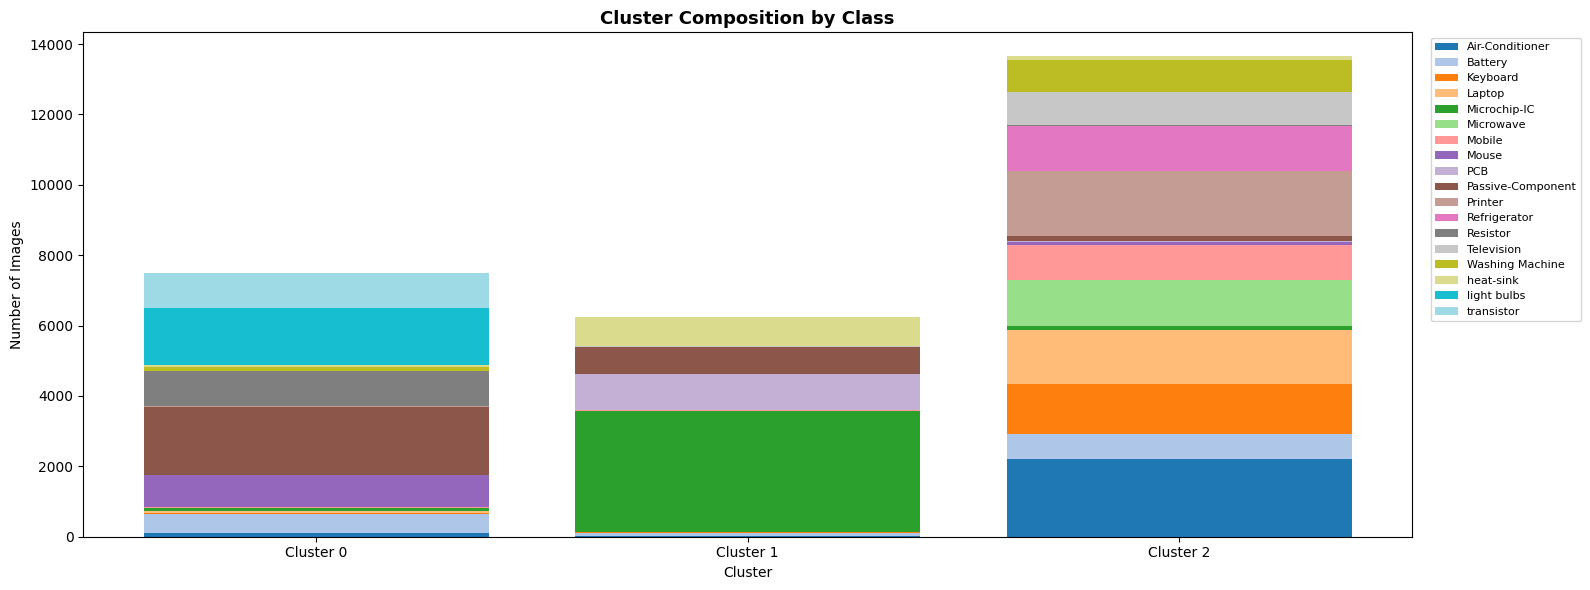

In [11]:
print("Cluster Composition — which classes fall in each cluster:\n")

for c in range(N_CLUSTERS):
    cluster_mask  = cluster_labels == c
    cluster_lbls  = all_labels[cluster_mask]
    print(f"Cluster {c} ({cluster_mask.sum()} samples):")
    for i, cls in enumerate(CLASS_NAMES):
        count = (cluster_lbls == i).sum()
        if count > 0:
            hazard = HAZARD_MAP.get(cls, "MEDIUM")
            bar    = "█" * (count // 10)
            print(f"  {cls:<35} {count:>5}  [{hazard}] {bar}")
    print()

# Stacked bar chart
cluster_class_counts = np.zeros((N_CLUSTERS, NUM_CLASSES))
for c in range(N_CLUSTERS):
    mask = cluster_labels == c
    for i in range(NUM_CLASSES):
        cluster_class_counts[c, i] = (all_labels[mask] == i).sum()

fig, ax = plt.subplots(figsize=(16, 6))
bottom = np.zeros(N_CLUSTERS)
colors = plt.cm.tab20(np.linspace(0, 1, NUM_CLASSES))
for i, cls in enumerate(CLASS_NAMES):
    ax.bar(range(N_CLUSTERS), cluster_class_counts[:, i],
           bottom=bottom, label=cls, color=colors[i])
    bottom += cluster_class_counts[:, i]

ax.set_title("Cluster Composition by Class", fontsize=13, fontweight="bold")
ax.set_xlabel("Cluster")
ax.set_ylabel("Number of Images")
ax.set_xticks(range(N_CLUSTERS))
ax.set_xticklabels([f"Cluster {c}" for c in range(N_CLUSTERS)])
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(CLUSTER_DIR, "cluster_composition.png"), dpi=150, bbox_inches="tight")
plt.show()

## Cell 11 — Save Clustering Summary

In [12]:
summary = {
    "n_clusters"       : N_CLUSTERS,
    "silhouette_score" : round(float(sil), 4),
    "adjusted_rand_index": round(float(ari), 4),
    "normalized_mutual_info": round(float(nmi), 4),
    "total_samples"    : int(len(all_labels)),
    "cluster_sizes"    : {str(c): int((cluster_labels == c).sum())
                          for c in range(N_CLUSTERS)},
}

with open(os.path.join(CLUSTER_DIR, "clustering_results.json"), "w") as f:
    json.dump(summary, f, indent=2)

print("Clustering summary saved.")
print(json.dumps(summary, indent=2))

Clustering summary saved.
{
  "n_clusters": 3,
  "silhouette_score": 0.0638,
  "adjusted_rand_index": 0.1612,
  "normalized_mutual_info": 0.3977,
  "total_samples": 27399,
  "cluster_sizes": {
    "0": 7500,
    "1": 6248,
    "2": 13651
  }
}
